In [ ]:
# TODO: list:
# 
# LSTM:
    # work on model architecture
    # create automating loading model once the stock prediction need to be made 
    # once the model is trained I do not want to train it every time because of time consumption, and I want to enhance the model using the latest data 


In [1]:
import numpy as np 
import pandas as pd 
from datetime import datetime
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

# Data Scrap

## yfinance approach: init db, insert data, update db, add new 

In [2]:
import sqlite3
from datetime import datetime, timedelta
import yfinance as yf


In [34]:
DB_NAME = 'stocks.db'


def initialize_database():
    """
    Create a SQLite database and the stock_data table.
    """

    conn = sqlite3.connect(DB_NAME)
    cursor = conn.cursor()
    cursor.execute("""
        CREATE TABLE IF NOT EXISTS stock_data (
            stock TEXT,
            date TEXT,
            open REAL,
            high REAL,
            low REAL,
            close REAL,
            volume INTEGER,
            dividends REAL,
            stock_splits REAL,
            PRIMARY KEY (stock, date)
        )
    """)
    conn.commit()
    conn.close()


def insert_data(ticker_symbol, data):
    """
    Insert historical data for a given stock into the database.
    """

    conn = sqlite3.connect(DB_NAME)
    cursor = conn.cursor()
    for _, row in data.iterrows():
        cursor.execute("""
            INSERT OR IGNORE INTO stock_data 
            (stock, date, open, high, low, close, volume, dividends, stock_splits)
            VALUES (?, ?, ?, ?, ?, ?, ?, ?, ?)
        """, (
            ticker_symbol,
            row['Date'].strftime('%Y-%m-%d') if isinstance(row['Date'], (datetime, pd.Timestamp)) else row['Date'],
            row['Open'],
            row['High'],
            row['Low'],
            row['Close'],
            row['Volume'],
            row['Dividends'],
            row['Stock Splits']
        ))
    conn.commit()
    conn.close()


def fetch_missing_data(ticker_symbol, start_date):
    """
    Fetch missing data for a stock from a given start date.
    """

    ticker = yf.Ticker(ticker_symbol)
    data = ticker.history(start=start_date)
    flat_data = data.reset_index()
    flat_data.insert(0, 'stock', ticker_symbol)
    return flat_data


def update_database():
    """
    Check if stock data is up to date and fetch missing data if needed.
    """

    conn = sqlite3.connect(DB_NAME)
    cursor = conn.cursor()
    cursor.execute("SELECT DISTINCT stock FROM stock_data")
    stocks = cursor.fetchall()
    stocks = [stock[0] for stock in stocks]
    
    for stock in stocks:
        cursor.execute("""
            SELECT MAX(date) FROM stock_data WHERE stock = ?
        """, (stock,))
        result = cursor.fetchone()
        last_date = result[0]
        
        if last_date:
            last_date = datetime.strptime(last_date, '%Y-%m-%d').date()
            if last_date < datetime.now().date() - timedelta(days=1):
                print(f"Updating data for {stock}...")
                missing_start = last_date + timedelta(days=1)
                new_data = fetch_missing_data(stock, missing_start)
                insert_data(stock, new_data)
    
    conn.close()


def add_new_stock(ticker_symbol):
    """
    Add a new stock's data to the database.
    """

    print(f"Fetching data for {ticker_symbol}...")
    ticker = yf.Ticker(ticker_symbol)
    historical_data = ticker.history(period='max')
    flat_data = historical_data.reset_index()
    flat_data.insert(0, 'stock', ticker_symbol)
    insert_data(ticker_symbol, flat_data)


def get_data_from_db(ticker_symbol, start_date, end_date):
    # TODO: think about data ranges I want to build the models in order to automate it, or I just want to train models on given ranges and then anchore it 

    """
    Fetch data for a given ticker symbol and date range from the database.

    Parameters:
        ticker_symbol (str): The stock symbol to fetch data for.
        start_date (str): The start date in 'YYYY-MM-DD' format.
        end_date (str): The end date in 'YYYY-MM-DD' format.
    """

    conn = sqlite3.connect(DB_NAME)
    query = """
        SELECT * FROM stock_data
        WHERE stock = ? AND date BETWEEN ? AND ?
        ORDER BY date ASC
    """
    data = pd.read_sql_query(query, conn, params=(ticker_symbol, start_date, end_date))
    conn.close()

    return data

In [4]:
# initialize_database()
# add_new_stock('NVDA')
update_database()

Updating data for AAPL...
Updating data for MSFT...
Updating data for NVDA...


# Preprocessing

## Download input from DB 

In [35]:
nvda = get_data_from_db('NVDA', '2019-01-01', '2025-01-15')
msft = get_data_from_db('MSFT', '2019-01-01', '2025-01-15')
aapl = get_data_from_db('AAPL', '2019-01-01', '2025-01-15')

## Split and Normzlize 

In [36]:
def split_data(data, train_ratio=0.8):
    """
    Split data into training and validation sets using train_test_split.

    Parameters:
        data (DataFrame): The stock data.
        train_ratio (float): The proportion of data to use for training.
    """

    train_data, validation_data = train_test_split(data, train_size=train_ratio, shuffle=False)
    return train_data, validation_data


def normalize_data(train_data, validation_data):
    """
    Normalize training and validation sets using MinMaxScaler.

    Parameters:
        train_data (DataFrame): Training data.
        validation_data (DataFrame): Validation data.
    """
    columns_to_normalize = ['open', 'high', 'low', 'close']

    scaler = MinMaxScaler(feature_range=(0, 1))
    
    scaler.fit(train_data[columns_to_normalize])
    
    train_data_normalized = train_data.copy()
    validation_data_normalized = validation_data.copy()
    
    train_data_normalized[columns_to_normalize] = scaler.transform(train_data[columns_to_normalize])
    validation_data_normalized[columns_to_normalize] = scaler.transform(validation_data[columns_to_normalize])
    
    
    return train_data_normalized, validation_data_normalized, scaler

In [37]:
train_nvda, validation_nvda = split_data(nvda)
train_msft, validation_msft = split_data(msft)
train_aapl, validation_aapl = split_data(aapl)

In [40]:
train_nvda_scaled, validation_nvda_scaled, scaler_nvda = normalize_data(train_nvda, validation_nvda)
train_msft_scaled, validation_msft_scaled, scaler_msft = normalize_data(train_msft, validation_msft)
train_aapl_scaled, validation_aapl_scaled, scaler_aapl = normalize_data(train_aapl, validation_aapl)

# Model

## Input (windows) preparation

In [41]:
import tensorflow as tf
import json

In [43]:
def create_input_train(train_scaled, validation_scaled, seq_length: int=5):

    # seq_length = 5
    train_targets = train_scaled['close'].to_numpy()

    train_inputs = np.array([
        train_targets[i:i + seq_length]
        for i in range(len(train_targets) - seq_length)
    ]).reshape(-1, seq_length, 1) 

    train_targets_multi_step = np.array([
        train_targets[i + seq_length]
        for i in range(len(train_targets) - seq_length)
    ]).reshape(-1, 1)

    train_df = tf.data.Dataset.from_tensor_slices((train_inputs, train_targets_multi_step)).batch(32)

    val_targets = validation_scaled['close'].to_numpy()

    val_inputs = np.array([
        val_targets[i:i + seq_length]
        for i in range(len(val_targets) - seq_length)
    ]).reshape(-1, seq_length, 1) 

    val_targets_multi_step = np.array([
        val_targets[i + seq_length]
        for i in range(len(val_targets) - seq_length)
    ]).reshape(-1, 1)

    val_df = tf.data.Dataset.from_tensor_slices((val_inputs, val_targets_multi_step)).batch(32)

    return train_df, val_df


In [44]:
train_nvda_df, validation_nvda_df = create_input_train(train_nvda_scaled, validation_nvda_scaled, 5)
train_msft_df, validation_msft_df = create_input_train(train_msft_scaled, validation_msft_scaled, 5)
train_aapl_df, validation_aapl_df = create_input_train(train_aapl_scaled, validation_aapl_scaled, 5)

## LSTM

In [46]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.losses import MeanSquaredError
from tensorflow.keras.metrics import RootMeanSquaredError
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_squared_error


In [66]:
def build_lstm_model():
    model = Sequential([
        LSTM(64, activation='tanh', return_sequences=True, input_shape=(5, 1)),
        LSTM(32, activation='relu', return_sequences=False),
        Dense(1)
    ])
    model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')

    training_params = {
    "batch_size": 32,
    "epochs": 1000,
    "validation_data": True
    }

    model_version = "1.0.0"

    return model, training_params, model_version

model, training_params, model_version = build_lstm_model()
model.summary()

c:\Users\Kacper\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 5, 64)          │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,345 (114.63 KB)

 Trainable params: 29,345 (114.63 KB)

 Non-trainable params: 0 (0.00 B)

In [67]:
# TODO: for each stock there should be the best model fitted. checks could be done using stochastic method that minimizes the error on training data? 
history = model.fit(
    # https://www.tensorflow.org/api_docs/python/tf/keras/Model#fit

    train_nvda_df, # x and y as there is tf.data.Dataset
    batch_size=training_params["batch_size"],
    epochs=training_params["epochs"],
    verbose=1, # progress bar
    validation_data=validation_nvda_df # tf.data.Dataset

)

Epoch 1/1000
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0067 - val_loss: 0.0234
Epoch 2/1000
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0292 - val_loss: 0.2062
Epoch 3/1000
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0083 - val_loss: 0.0167
Epoch 4/1000
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0231 - val_loss: 0.4571
Epoch 5/1000
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0023 - val_loss: 0.0338
Epoch 6/1000
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0053 - val_loss: 0.0309
Epoch 7/1000
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0013 - val_loss: 0.0130
Epoch 8/1000
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 9.0941e-04 - val_loss: 0.0181
Epoch 9/1000
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 3.8804e-04 - val_loss: 0.0236
Epoch 10/1000
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2.2566e-04 - val_loss: 0.0214
Epoch 11/1000
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.9760e-04 - val_loss: 0.0204
Epoch 12/1000
38/38 ━━━━━━━━━━━━━━━━

In [68]:
def extract_model_architecture(model, training_params):
    """
    Extracts model architecture and training parameters dynamically.
    Parameters:
        model: The trained Keras model.
        training_params: Dictionary containing training parameters like batch_size and epochs.
    Returns:
        dict: Model architecture and training parameters in a dictionary.
    """ 

    model_config = model.get_config()
    layers = []
    for layer in model_config['layers']:
        layer_info = {
            'type': layer['class_name'],
            'config': layer['config']
        }
        layers.append(layer_info)
    
    optimizer_config = model.optimizer.get_config()
    
    model_architecture = {
        "layers": layers,
        "optimizer": optimizer_config,
        "loss": model.loss,
        "training_params": training_params
    }
    return model_architecture

In [69]:
model_architecture = extract_model_architecture(model, training_params)

In [70]:
train_nvda_predictions = model.predict(train_nvda_df)
validation_nvda_predictions = model.predict(validation_nvda_df)


38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


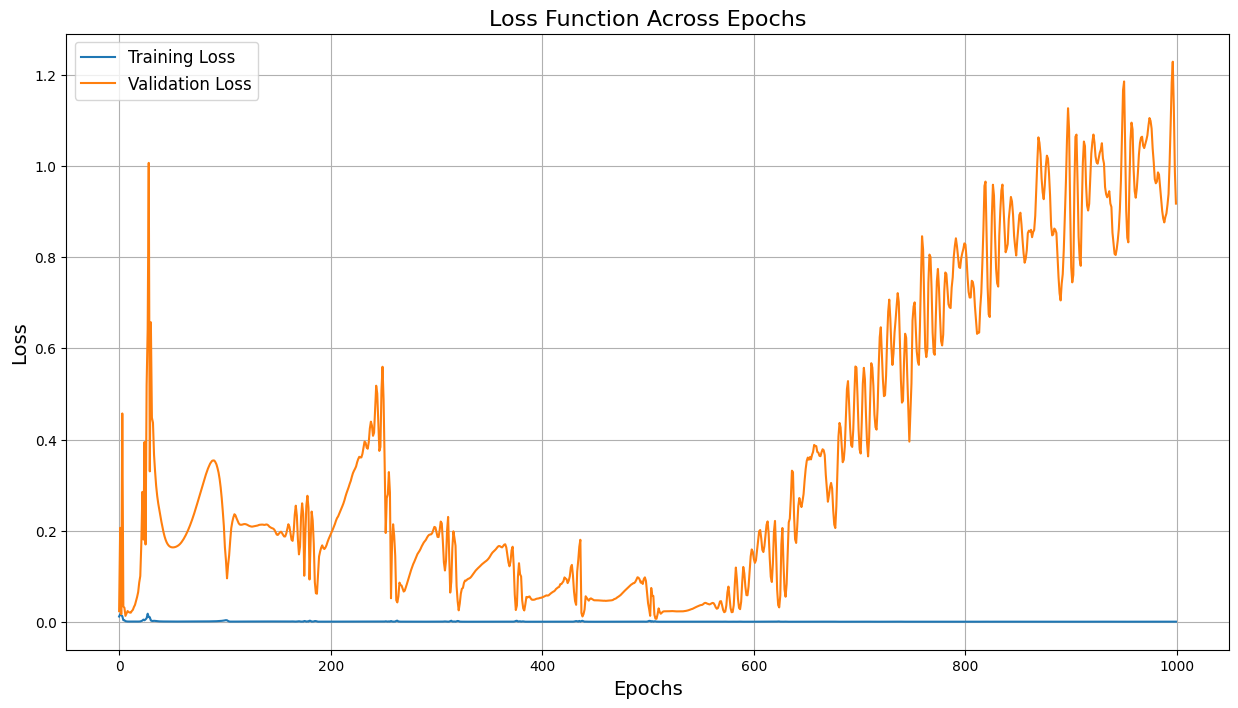

In [71]:
# TODO: have to understand what happens with loss function 

import matplotlib.pyplot as plt

def plot_loss_function(history):

    plt.figure(figsize=(15, 8))

    plt.plot(history.history['loss'], label='Training Loss')
    
    if 'val_loss' in history.history:
        plt.plot(history.history['val_loss'], label='Validation Loss')
    
    plt.title('Loss Function Across Epochs', fontsize=16)
    plt.xlabel('Epochs', fontsize=14)
    plt.ylabel('Loss', fontsize=14)
    plt.legend(fontsize=12)
    plt.grid(True)
    plt.show()

plot_loss_function(history)

In [52]:
def denormalize_predictions(predictions, scaler):
    """
    Denormalize predictions using the fitted scaler.
    Create a placeholder array with the same number of features as the scaler was fitted on,
    Insert the predictions into the 'close' column position (index 3 in this case),
    Extract the denormalized 'close' column

    Parameters:
        predictions: Normalized predictions for the 'close' column (2D array of shape (n, 1)).
        scaler (MinMaxScaler): Fitted scaler.

    """
    
    placeholder = np.zeros((predictions.shape[0], len(scaler.feature_names_in_)))
    placeholder[:, -1] = predictions.flatten()
    denorm_placeholder = scaler.inverse_transform(placeholder)
    denorm_predictions = denorm_placeholder[:, -1]
    return denorm_predictions

In [53]:
train_nvda_predictions_denorm = denormalize_predictions(train_nvda_predictions, scaler_nvda)
validation_nvda_predictions_denorm = denormalize_predictions(validation_nvda_predictions, scaler_nvda)

In [54]:
def calculate_rmse(train_predictions, val_predictions, df_test):
    """
    Calculate RMSE for the training and validation sets.

    Parameters:
        train_predictions (numpy array): Denormalized predicted values for training set.
        val_predictions (numpy array): Denormalized predicted values for validation set.
        df_test (DataFrame): Original dataset with 'close' column.
    """

    close_true_train = df_test['close'].iloc[:len(train_predictions)].values
    close_true_val = df_test['close'].iloc[len(train_predictions):len(train_predictions) + len(val_predictions)].values

    train_rmse = np.sqrt(mean_squared_error(close_true_train, train_predictions))
    val_rmse = np.sqrt(mean_squared_error(close_true_val, val_predictions))

    return train_rmse, val_rmse

In [55]:
train_rmse, val_rmse = calculate_rmse(train_nvda_predictions_denorm, validation_nvda_predictions_denorm, nvda)

In [56]:
train_rmse

0.9030621404176012

In [57]:
val_rmse

10.297041407973358

In [ ]:
# TODO: calculate r2 

In [ ]:
# TODO: model perform much batter on train dataset: big overfitting, maybe use some normalization? 

In [58]:
def create_prediction_dataframe(train_predictions, val_predictions, df_test, train_rmse, val_rmse, seq_length, model_architecture, model_version):
    """
    Create a dataframe with true and predicted values, along with additional metadata,
    and assign RMSE values for train and validation rows.

    Parameters:
        train_predictions (numpy array): Denormalized predicted values for training set.
        val_predictions (numpy array): Denormalized predicted values for validation set.
        df_test (DataFrame): Original dataset with stock, date, and close.
        train_rmse (float): RMSE value for the training set.
        val_rmse (float): RMSE value for the validation set.

    """

    train_predictions = train_predictions.flatten()
    val_predictions = val_predictions.flatten()
    
    train_start_idx = seq_length
    val_start_idx = seq_length + len(train_predictions)

    stocks_train = df_test['stock'].iloc[train_start_idx:train_start_idx + len(train_predictions)].values
    stocks_val = df_test['stock'].iloc[val_start_idx:val_start_idx + len(val_predictions)].values

    dates_train = df_test['date'].iloc[train_start_idx:train_start_idx + len(train_predictions)].values
    dates_val = df_test['date'].iloc[val_start_idx:val_start_idx + len(val_predictions)].values

    close_true_train = df_test['close'].iloc[train_start_idx:train_start_idx + len(train_predictions)].values
    close_true_val = df_test['close'].iloc[val_start_idx:val_start_idx + len(val_predictions)].values

    combined_data = {
        'stock': np.concatenate([stocks_train, stocks_val]),
        'date': np.concatenate([dates_train, dates_val]),
        'close_true': np.concatenate([close_true_train, close_true_val]),
        'close_predicted': np.concatenate([train_predictions, val_predictions]),
        'dataset_point': ['train'] * len(train_predictions) + ['val'] * len(val_predictions),
        'model_version': [model_version] * (len(train_predictions) + len(val_predictions)),
        'rmse_value': [train_rmse] * len(train_predictions) + [val_rmse] * len(val_predictions),
        'model_architecture': [json.dumps(model_architecture)] * (len(train_predictions) + len(val_predictions)),
    }

    df = pd.DataFrame(combined_data)
    return df


In [59]:
prediction_df = create_prediction_dataframe(
    train_nvda_predictions_denorm, validation_nvda_predictions_denorm, nvda, train_rmse, val_rmse, 5, model_architecture, model_version
)


In [60]:
prediction_df

,stock,date,close_true,close_predicted,dataset_point,model_version,rmse_value,model_architecture
0,NVDA,2019-01-09,3.535810,3.448507,train,1.0.0,0.903062,"{""layers"": [{""type"": ""InputLayer"", ""config"": {..."
1,NVDA,2019-01-10,3.601527,3.484124,train,1.0.0,0.903062,"{""layers"": [{""type"": ""InputLayer"", ""config"": {..."
2,NVDA,2019-01-11,3.690802,3.545752,train,1.0.0,0.903062,"{""layers"": [{""type"": ""InputLayer"", ""config"": {..."
3,NVDA,2019-01-14,3.730728,3.600049,train,1.0.0,0.903062,"{""layers"": [{""type"": ""InputLayer"", ""config"": {..."
4,NVDA,2019-01-15,3.716593,3.644867,train,1.0.0,0.903062,"{""layers"": [{""type"": ""InputLayer"", ""config"": {..."
...,...,...,...,...,...,...,...,...
1504,NVDA,2024-12-31,134.289993,126.073011,val,1.0.0,10.297041,"{""layers"": [{""type"": ""InputLayer"", ""config"": {..."
1505,NVDA,2025-01-02,138.309998,127.046453,val,1.0.0,10.297041,"{""layers"": [{""type"": ""InputLayer"", ""config"": {..."
1506,NVDA,2025-01-03,144.470001,123.847675,val,1.0.0,10.297041,"{""layers"": [{""type"": ""InputLayer"", ""config"": {..."
1507,NVDA,2025-01-06,149.429993,121.713121,val,1.0.0,10.297041,"{""layers"": [{""type"": ""InputLayer"", ""config"": {..."


In [ ]:
# TODO: store to db the table with model versions metrics 

# Store output

## Save model 

In [369]:
import os

def save_model(model, model_version, folder="models"):
    """
    Save the trained model to the specified folder with version name in the filename.

    Parameters:
        model (tf.keras.Model): The trained Keras model to save.
        version (str): The version name (e.g., '1.0.0') to include in the filename.
        folder (str): The folder where the model will be saved. Defaults to 'models'.
    """

    if not os.path.exists(folder):
        os.makedirs(folder)

    filename = f"model_v{model_version}.h5"
    filepath = os.path.join(folder, filename)

    model.save(filepath)

In [370]:
save_model(model, model_version)

## Save data to db 

In [61]:
def initialize_predictions_table():
    """
    Create a table to store model predictions in the database.
    """
    
    conn = sqlite3.connect(DB_NAME)
    cursor = conn.cursor()
    cursor.execute("""
        CREATE TABLE IF NOT EXISTS predictions (
            stock TEXT,
            date TEXT,
            close_true REAL,
            close_predicted REAL,
            dataset_point TEXT,
            model_version TEXT,
            rmse_value REAL,
            model_architecture TEXT,
            PRIMARY KEY (stock, date, model_version)
        )
    """)
    conn.commit()
    conn.close()

def insert_predictions(predictions_data):
    """
    Insert or update predictions into the predictions table.

    """
    
    conn = sqlite3.connect(DB_NAME)
    cursor = conn.cursor()

    for _, row in predictions_data.iterrows():
        cursor.execute("""
            INSERT OR REPLACE INTO predictions 
            (stock, date, close_true, close_predicted, dataset_point, model_version, rmse_value, model_architecture)
            VALUES (?, ?, ?, ?, ?, ?, ?, ?)
        """, (
            row['stock'],
            row['date'],
            row['close_true'],
            row['close_predicted'],
            row['dataset_point'],
            row['model_version'],
            row['rmse_value'],
            row['model_architecture']
        ))

    conn.commit()
    conn.close()


In [62]:
# initialize_predictions_table()
insert_predictions(prediction_df)

# Visualization

In [ ]:
# TODO: create a good visualization based on output df, include the rmse on plot, separate train and val data for both true and predicted, include dates on x axis and label the axes, 

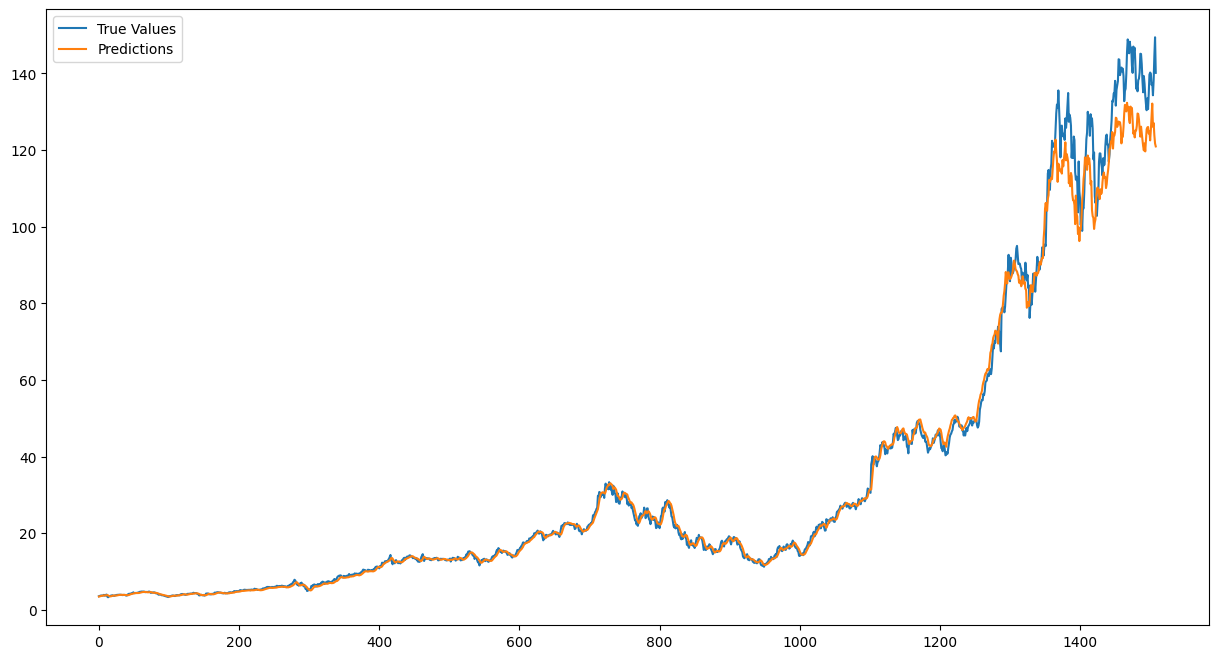

In [63]:
import matplotlib.pyplot as plt
plt.figure(figsize=(15, 8))
plt.plot(prediction_df['close_true'], label="True Values")
plt.plot(prediction_df['close_predicted'], label="Predictions")
plt.legend()
plt.show()

# Tests

## Operating on created DB

In [ ]:
def print_top_records():
    """
    Fetch and print the top 10 records from the stock_data table.
    """
    
    conn = sqlite3.connect(DB_NAME)
    cursor = conn.cursor()

    query = "SELECT * FROM stock_data LIMIT 100;"
    cursor.execute(query)  

    records = cursor.fetchall()
    column_names = [description[0] for description in cursor.description]
    df = pd.DataFrame(records, columns=column_names)
    print(df)
    
    conn.close()

print_top_records()

   stock        date      open      high       low     close      volume  \
0   MSFT  1986-03-13  0.054485  0.062498  0.054485  0.059827  1031788800   
1   MSFT  1986-03-14  0.059827  0.063032  0.059827  0.061963   308160000   
2   MSFT  1986-03-17  0.061963  0.063566  0.061963  0.063032   133171200   
3   MSFT  1986-03-18  0.063032  0.063566  0.060895  0.061429    67766400   
4   MSFT  1986-03-19  0.061429  0.061963  0.059827  0.060361    47894400   
..   ...         ...       ...       ...       ...       ...         ...   
95  MSFT  1986-07-29  0.065169  0.065703  0.062498  0.063566    14054400   
96  MSFT  1986-07-30  0.063566  0.063566  0.059293  0.061429    26409600   
97  MSFT  1986-07-31  0.061429  0.061963  0.060895  0.060895    15638400   
98  MSFT  1986-08-01  0.060895  0.061429  0.059827  0.060361    12902400   
99  MSFT  1986-08-04  0.060361  0.060361  0.058758  0.060361    12441600   

    dividends  stock_splits  
0         0.0           0.0  
1         0.0           0.0

## Train and Val vs Normalized Train and Val 

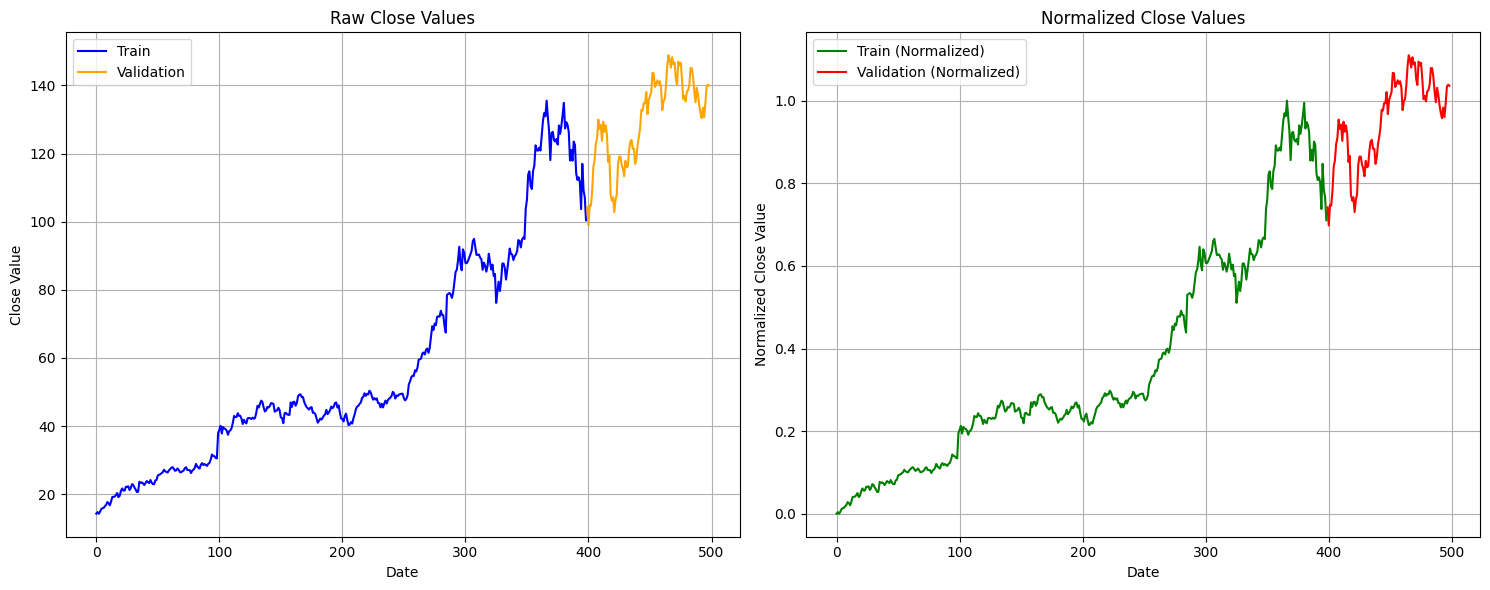

In [37]:
import matplotlib.pyplot as plt

def plot_raw_and_normalized(train_data, validation_data, train_normalized, validation_normalized):
    """
    Create a subplot with raw and normalized close values for train and validation datasets.
    """

    fig, axs = plt.subplots(1, 2, figsize=(15, 6))

    axs[0].plot(train_data.index, train_data['close'], label='Train', color='blue')
    axs[0].plot(validation_data.index, validation_data['close'], label='Validation', color='orange')
    axs[0].set_title("Raw Close Values")
    axs[0].set_xlabel("Date")
    axs[0].set_ylabel("Close Value")
    axs[0].legend()
    axs[0].grid(True)

    axs[1].plot(train_normalized.index, train_normalized['close'], label='Train (Normalized)', color='green')
    axs[1].plot(validation_normalized.index, validation_normalized['close'], label='Validation (Normalized)', color='red')
    axs[1].set_title("Normalized Close Values")
    axs[1].set_xlabel("Date")
    axs[1].set_ylabel("Normalized Close Value")
    axs[1].legend()
    axs[1].grid(True)

    plt.tight_layout()
    plt.show()

plot_raw_and_normalized(train_df_test, validation_df_test, train_df_test_scaled, validation_df_test_scaled)